In [2]:
!pip install diffusers transformers accelerate

   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   ---------- ----------------------------- 1.3/5.0 MB 5.9 MB/s eta 0:00:01
   ----------------------------------- ---- 4.5/5.0 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 5.0/5.0 MB 11.5 MB/s  0:00:00

   ------------- -------------------------- 1/3 [importlib_metadata]
   -------------------------- ------------- 2/3 [diffusers]
   -------------------------- ------------- 2/3 [diffusers]
   -------------------------- ------------- 2/3 [diffusers]
   -------------------------- ------------- 2/3 [diffusers]
   -------------------------- ------------- 2/3 [diffusers]
   -------------------------- ------------- 2/3 [diffusers]
   -------------------------- ------------- 2/3 [diffusers]
   -------------------------- ------------- 2/3 [diffusers]
   -------------------------- ------------- 2/3 [diffusers]
   ----------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\rosha\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers import StableDiffusionInpaintPipeline

In [4]:
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
).to("cuda")

pipe.safety_checker = None

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

C:\Users\rosha\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rosha\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.bin:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\rosha\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\rosha\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch C:\Users\rosha\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\rosha\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


408 612


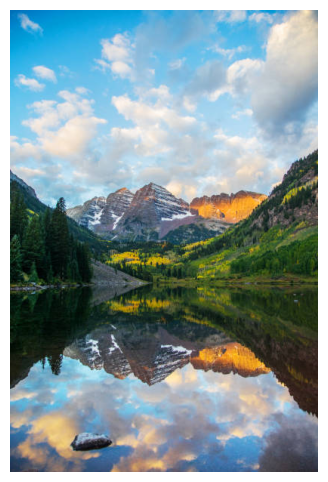

In [9]:
image = Image.open("images/img2.jpg").convert("RGB")
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
width, height = image.size
print(width, height)

(np.float64(-0.5), np.float64(663.5), np.float64(611.5), np.float64(-0.5))

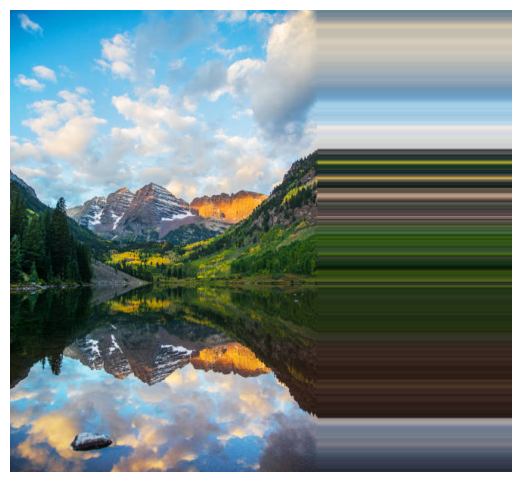

In [10]:
expand_pixels = 256
new_width = width + expand_pixels
new_height = height

# Use edge pixels instead of black to avoid harsh seam
new_image = Image.new("RGB", (new_width, new_height))
new_image.paste(image, (0, 0))

# Fill the new region by stretching the right edge column
right_edge = image.crop((width - 1, 0, width, height))  # 1-pixel wide strip
right_edge_stretched = right_edge.resize((expand_pixels, height))
new_image.paste(right_edge_stretched, (width, 0))

plt.figure(figsize=(8, 6))
plt.imshow(new_image)
plt.axis("off")

(512, 512)
(512, 512)


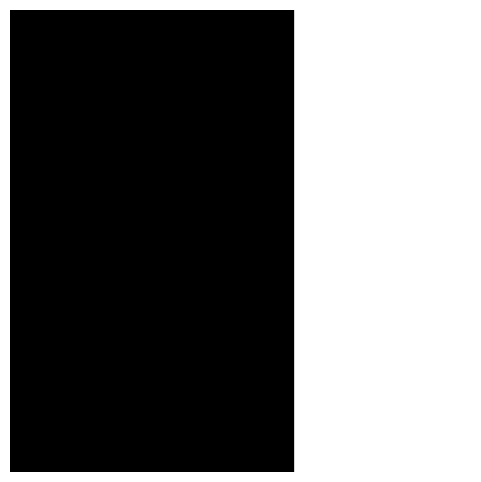

In [11]:
mask = np.zeros((new_height, new_width), dtype=np.uint8)
mask[:, width:] = 255  # white = region to generate
mask_image = Image.fromarray(mask)

# SD v1.5 inpainting works best at 512x512
new_image_resized = new_image.resize((512, 512))
mask_image_resized = mask_image.resize((512, 512), Image.NEAREST)

plt.figure(figsize=(6, 6))
plt.imshow(mask_image_resized, cmap="gray")
plt.axis("off")
print(new_image_resized.size)   # (512, 512)
print(mask_image_resized.size)  # (512, 512)

In [12]:
prompt = (
    "photorealistic mountain landscape, rocky peaks with snow, "
    "alpine lake reflection, lush green forest, golden sunrise light, "
    "blue sky with clouds, highly detailed, 8k"
)
negative_prompt = (
    "blurry, low quality, distorted, watermark, text, "
    "extra objects, bad anatomy, ugly, duplicate"
)

result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=new_image_resized,
    mask_image=mask_image_resized,
    num_inference_steps=50,
    guidance_scale=8.5,
    strength=0.99         # high strength = more creative fill in masked region
).images[0]

  0%|          | 0/49 [00:00<?, ?it/s]

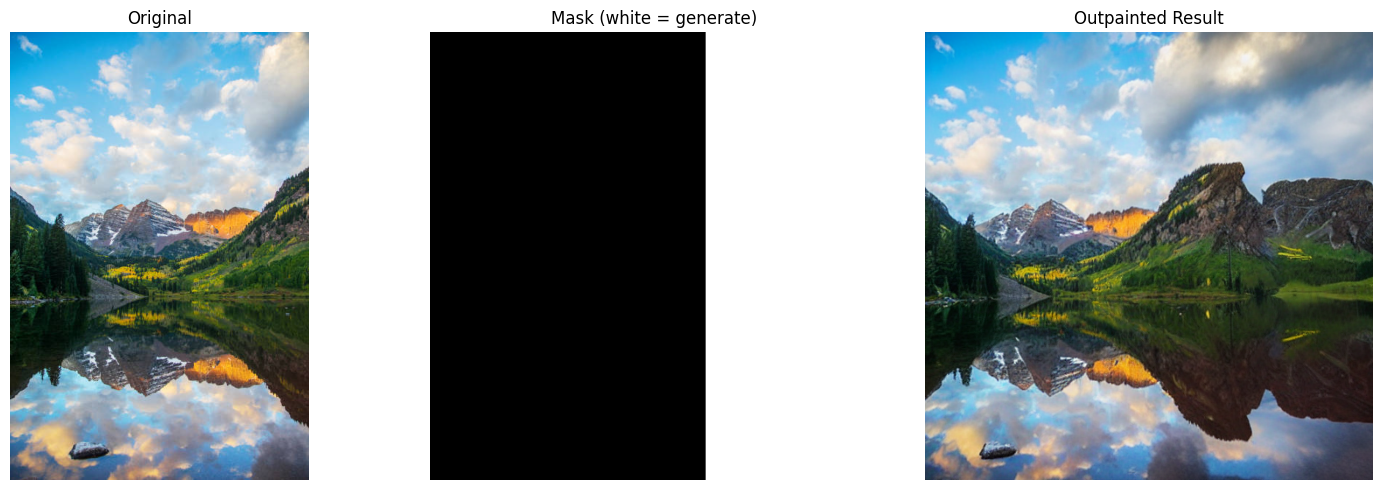

Saved!


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask_image_resized, cmap="gray")
axes[1].set_title("Mask (white = generate)")
axes[1].axis("off")

axes[2].imshow(result)
axes[2].set_title("Outpainted Result")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Save result
result.save("outpainted_result.png")
print("Saved!")

Original size: 2268 x 4032


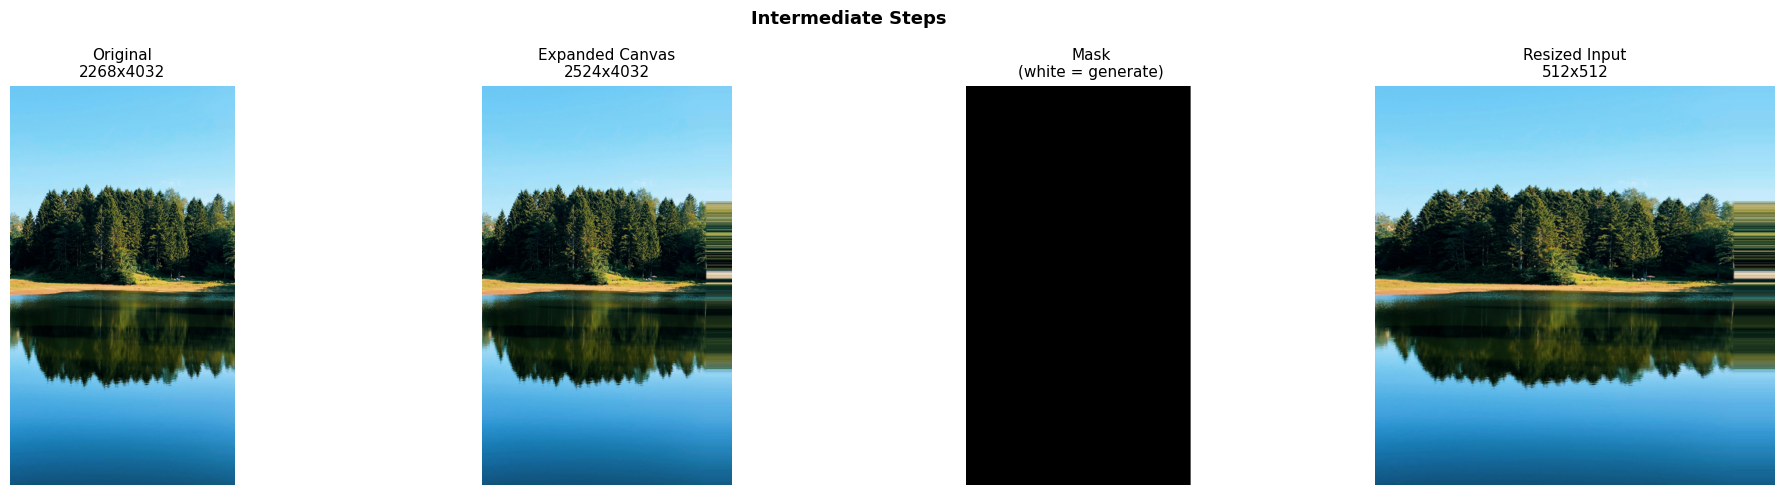


Running inpainting... please wait ⏳


  0%|          | 0/49 [00:00<?, ?it/s]

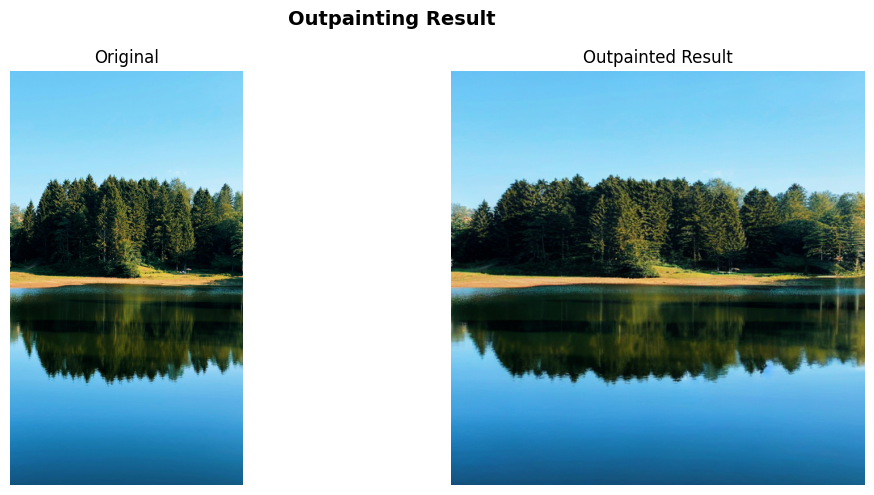

✅ Saved as outpainted_img3.png


In [14]:
# ============================================================
# CELL - Full Outpainting Pipeline for img3.jpg (expand right)
# ============================================================
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ---------- 1. Load & show original ----------
image = Image.open("images/img3.jpg").convert("RGB")
width, height = image.size
print(f"Original size: {width} x {height}")

# ---------- 2. Build expanded canvas ----------
expand_pixels = 256
new_width = width + expand_pixels

new_image = Image.new("RGB", (new_width, height))
new_image.paste(image, (0, 0))

# Fill new region with stretched right edge (avoids black seam)
right_edge = image.crop((width - 1, 0, width, height))
right_edge_stretched = right_edge.resize((expand_pixels, height))
new_image.paste(right_edge_stretched, (width, 0))

# ---------- 3. Build mask ----------
mask = np.zeros((height, new_width), dtype=np.uint8)
mask[:, width:] = 255          # white = region to generate
mask_image = Image.fromarray(mask)

# ---------- 4. Resize to 512x512 for SD v1.5 ----------
new_image_resized = new_image.resize((512, 512))
mask_image_resized = mask_image.resize((512, 512), Image.NEAREST)

# ---------- 5. Show all intermediate images ----------
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image)
axes[0].set_title(f"Original\n{width}x{height}", fontsize=11)
axes[0].axis("off")

axes[1].imshow(new_image)
axes[1].set_title(f"Expanded Canvas\n{new_width}x{height}", fontsize=11)
axes[1].axis("off")

axes[2].imshow(mask_image, cmap="gray")
axes[2].set_title("Mask\n(white = generate)", fontsize=11)
axes[2].axis("off")

axes[3].imshow(new_image_resized)
axes[3].set_title("Resized Input\n512x512", fontsize=11)
axes[3].axis("off")

plt.suptitle("Intermediate Steps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ---------- 6. Run inpainting ----------
prompt = (
    "photorealistic lake landscape, calm blue water reflection, "
    "dense green pine forest, sandy shoreline, clear blue sky, "
    "bright sunny day, highly detailed, natural lighting, 8k"
)
negative_prompt = (
    "blurry, low quality, distorted, watermark, text, "
    "extra objects, bad anatomy, ugly, duplicate, dark"
)

print("\nRunning inpainting... please wait ⏳")
result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=new_image_resized,
    mask_image=mask_image_resized,
    num_inference_steps=50,
    guidance_scale=8.5,
    strength=0.99
).images[0]

# ---------- 7. Show final result ----------
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

axes2[0].imshow(image)
axes2[0].set_title("Original", fontsize=12)
axes2[0].axis("off")

axes2[1].imshow(result)
axes2[1].set_title("Outpainted Result", fontsize=12)
axes2[1].axis("off")

plt.suptitle("Outpainting Result", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ---------- 8. Save ----------
result.save("outpainted_img3.png")
print("✅ Saved as outpainted_img3.png")

Original size: 2268 x 4032


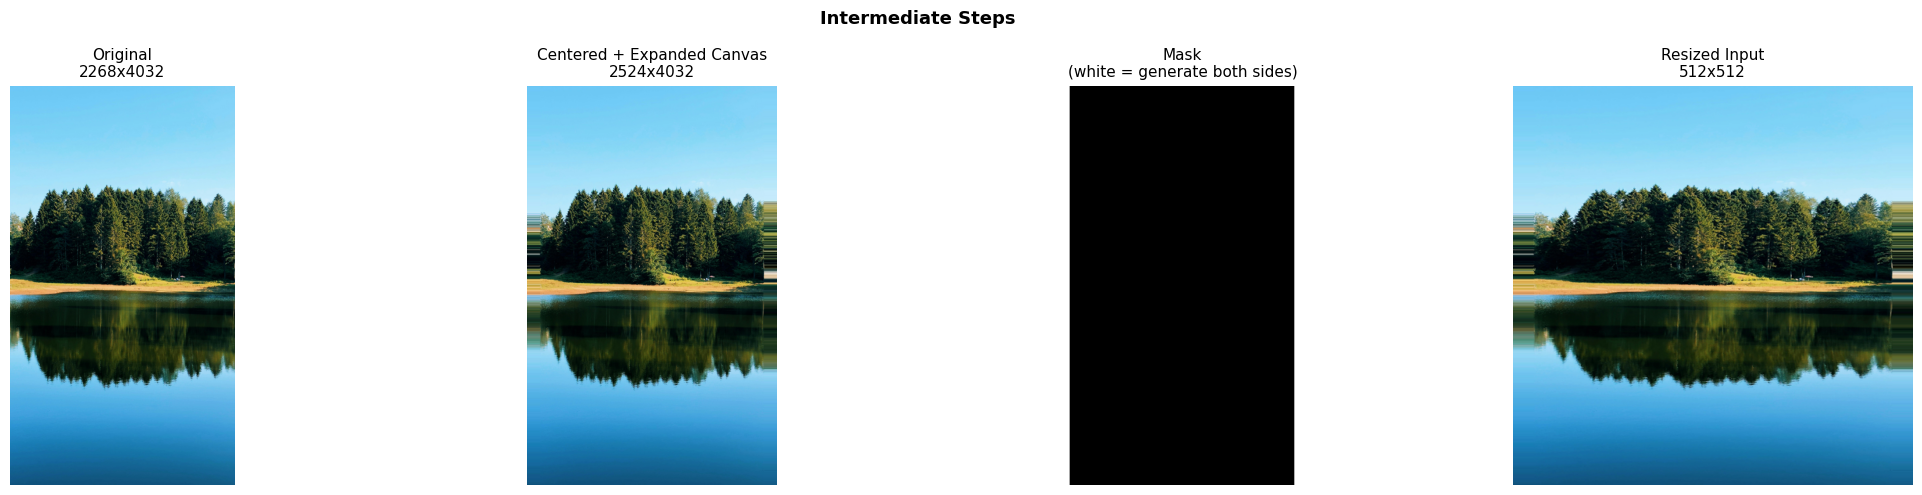


Running inpainting... please wait ⏳


  0%|          | 0/49 [00:00<?, ?it/s]

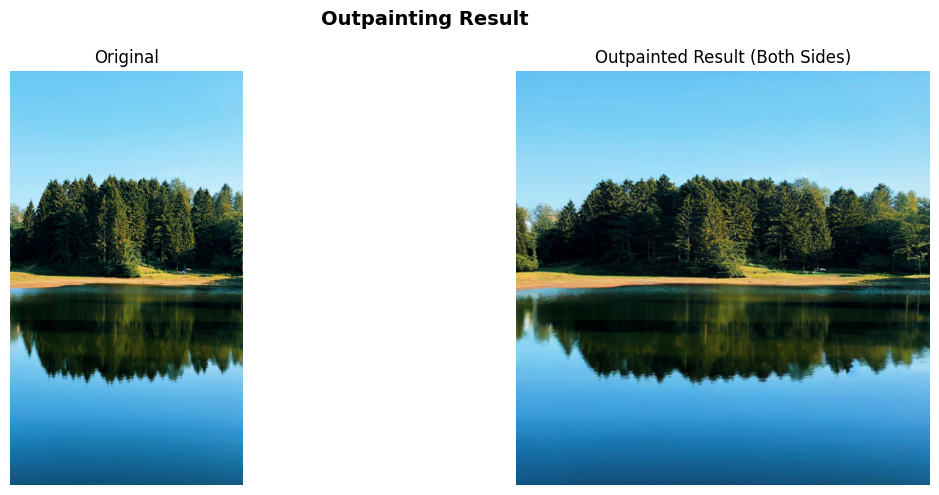

Saved as outpainted_img3_centered.png


In [15]:
#Center image, expand LEFT + RIGHT
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

#Load & show original
image = Image.open("images/img3.jpg").convert("RGB")
width, height = image.size
print(f"Original size: {width} x {height}")

#Build expanded canvas (expand both sides)
expand_each_side = 128          # 128px left + 128px right = 256px total
new_width = width + (expand_each_side * 2)
offset_x = expand_each_side    # original starts here

new_image = Image.new("RGB", (new_width, height))

# Fill LEFT region with stretched left edge
left_edge = image.crop((0, 0, 1, height))
left_edge_stretched = left_edge.resize((expand_each_side, height))
new_image.paste(left_edge_stretched, (0, 0))

# Paste original in center
new_image.paste(image, (offset_x, 0))

# Fill RIGHT region with stretched right edge
right_edge = image.crop((width - 1, 0, width, height))
right_edge_stretched = right_edge.resize((expand_each_side, height))
new_image.paste(right_edge_stretched, (offset_x + width, 0))

#Build mask (white on BOTH sides)
mask = np.zeros((height, new_width), dtype=np.uint8)
mask[:, :expand_each_side] = 255                        
mask[:, offset_x + width:] = 255                       
mask_image = Image.fromarray(mask)

#Resize to 512x512 for SD v1.5
new_image_resized = new_image.resize((512, 512))
mask_image_resized = mask_image.resize((512, 512), Image.NEAREST)

#Show all intermediate images
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(image)
axes[0].set_title(f"Original\n{width}x{height}", fontsize=11)
axes[0].axis("off")

axes[1].imshow(new_image)
axes[1].set_title(f"Centered + Expanded Canvas\n{new_width}x{height}", fontsize=11)
axes[1].axis("off")

axes[2].imshow(mask_image, cmap="gray")
axes[2].set_title("Mask\n(white = generate both sides)", fontsize=11)
axes[2].axis("off")

axes[3].imshow(new_image_resized)
axes[3].set_title("Resized Input\n512x512", fontsize=11)
axes[3].axis("off")

plt.suptitle("Intermediate Steps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#Run inpainting
prompt = (
    "photorealistic lake landscape, calm blue water reflection, "
    "dense green pine forest, sandy shoreline, clear blue sky, "
    "bright sunny day, highly detailed, natural lighting, 8k"
)
negative_prompt = (
    "blurry, low quality, distorted, watermark, text, "
    "extra objects, bad anatomy, ugly, duplicate, dark"
)

print("\nRunning inpainting... please wait ⏳")
result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=new_image_resized,
    mask_image=mask_image_resized,
    num_inference_steps=50,
    guidance_scale=8.5,
    strength=0.99
).images[0]

#Show final result
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

axes2[0].imshow(image)
axes2[0].set_title("Original", fontsize=12)
axes2[0].axis("off")

axes2[1].imshow(result)
axes2[1].set_title("Outpainted Result (Both Sides)", fontsize=12)
axes2[1].axis("off")

plt.suptitle("Outpainting Result", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#Save 
result.save("outpainted_img3_centered.png")
print("Saved as outpainted_img3_centered.png")